###Importing Necessary Libraries and Loading the AirBNB Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

# Load the dataset
file_path = "/content/Airbnb_Open_Data.csv"
df = pd.read_csv(file_path)
print(df)


Saving Airbnb_Open_Data.csv to Airbnb_Open_Data.csv
             id                                              NAME  \
0       1001254                Clean & quiet apt home by the park   
1       1002102                             Skylit Midtown Castle   
2       1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3       1002755                                               NaN   
4       1003689  Entire Apt: Spacious Studio/Loft by central park   
...         ...                                               ...   
102594  6092437                        Spare room in Williamsburg   
102595  6092990                     Best Location near Columbia U   
102596  6093542                    Comfy, bright room in Brooklyn   
102597  6094094                  Big Studio-One Stop from Midtown   
102598  6094647                              585 sf Luxury Studio   

            host id host_identity_verified    host name neighbourhood group  \
0       80014485718            unconfirm

/tmp/ipykernel_4652/3517869071.py:9: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


##Check the column names in the Dataset

Check for Missing Values

In [2]:
print(df)
print(df.columns)

print(df.isnull().sum())

             id                                              NAME  \
0       1001254                Clean & quiet apt home by the park   
1       1002102                             Skylit Midtown Castle   
2       1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3       1002755                                               NaN   
4       1003689  Entire Apt: Spacious Studio/Loft by central park   
...         ...                                               ...   
102594  6092437                        Spare room in Williamsburg   
102595  6092990                     Best Location near Columbia U   
102596  6093542                    Comfy, bright room in Brooklyn   
102597  6094094                  Big Studio-One Stop from Midtown   
102598  6094647                              585 sf Luxury Studio   

            host id host_identity_verified    host name neighbourhood group  \
0       80014485718            unconfirmed     Madaline            Brooklyn   
1       52335

##Handle Missing Values

This code ensures that the 'last review' column is properly formatted as datetime, missing values in key columns are appropriately handled, and incomplete records are removed, preparing the dataset for further analysis or visualization.

In [3]:
print(df)
# Convert 'last review' to datetime and handle errors
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
print(df)
# Fill missing values
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)
print(df)
# Drop records with missing 'name' or 'host name'
df.dropna(subset=['NAME', 'host name'], inplace=True)
print(df)

             id                                              NAME  \
0       1001254                Clean & quiet apt home by the park   
1       1002102                             Skylit Midtown Castle   
2       1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3       1002755                                               NaN   
4       1003689  Entire Apt: Spacious Studio/Loft by central park   
...         ...                                               ...   
102594  6092437                        Spare room in Williamsburg   
102595  6092990                     Best Location near Columbia U   
102596  6093542                    Comfy, bright room in Brooklyn   
102597  6094094                  Big Studio-One Stop from Midtown   
102598  6094647                              585 sf Luxury Studio   

            host id host_identity_verified    host name neighbourhood group  \
0       80014485718            unconfirmed     Madaline            Brooklyn   
1       52335

##Correct Data Types

Ensure that all columns have the correct data types.

In [4]:
 # Remove dollar signs and convert to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4652/2579271900.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_4652/2579271900.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


##Remove Duplicates

Check for and remove any duplicate records.

In [5]:
df.drop_duplicates(inplace=True)

Confirm Data Cleaning

Verify that the data cleaning steps were successful.

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

Descriptive Statistics

In [7]:
print(df.describe())

                 id       host id            lat           long  \
count  1.014100e+05  1.014100e+05  101402.000000  101402.000000   
mean   2.920959e+07  4.926155e+10      40.728082     -73.949663   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.507574e+07  2.459183e+10      40.688730     -73.982570   
50%    2.922911e+07  4.912069e+10      40.722300     -73.954440   
75%    4.328308e+07  7.399747e+10      40.762750     -73.932340   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   
std    1.626820e+07  2.853703e+10       0.055850       0.049474   

       Construction year          price    service fee  minimum nights  \
count      101210.000000  101171.000000  101142.000000   101016.000000   
mean         2012.486908     625.381008     125.043998        8.113744   
min          2003.000000      50.000000      10.000000    -1223.000000   
25%          2007.000000     340.000000      68.000000        2.000000   
50%          2012.000000  

Visualization

##Distribution of Prices

Plot the distribution of listing prices.

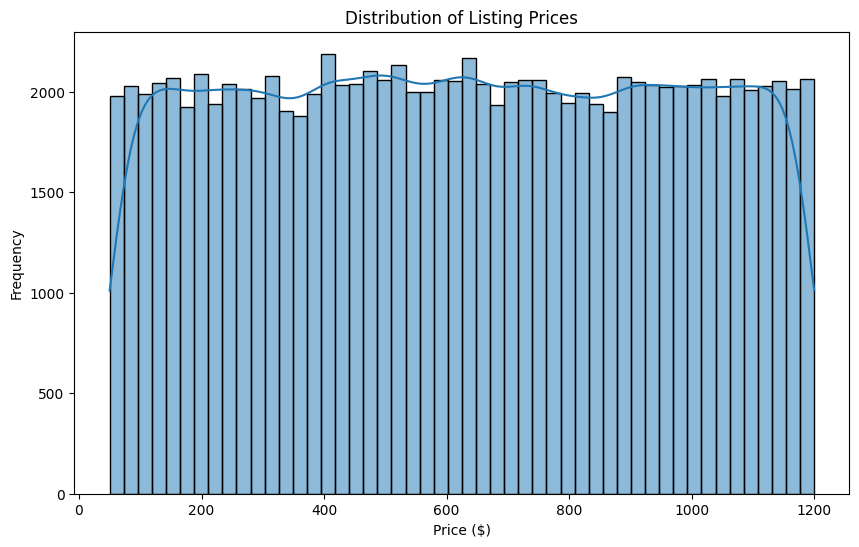

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

###Insights: Distribution of Prices
The distribution of listing prices is heavily right-skewed, indicating that most listings are at lower price points, with a long tail of fewer, very expensive listings. There are likely significant outliers at the higher end.

##Room Type Analysis

Analyze the distribution of different room types.

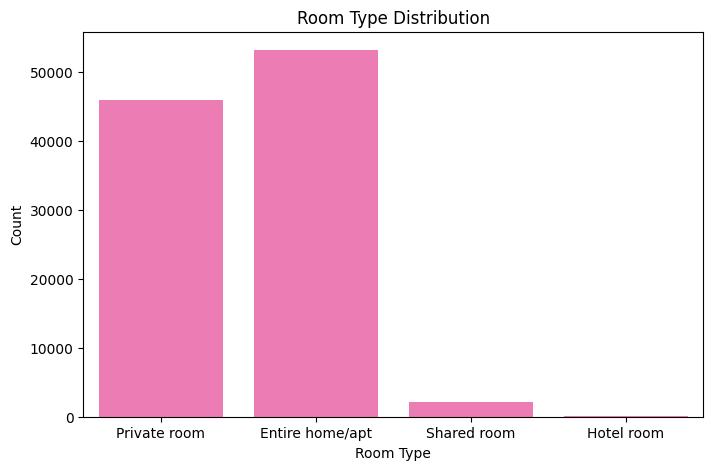

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='room type', data=df , color='hotpink')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

##Insights: Room Type Distribution
The room type distribution shows that 'Entire home/apt' and 'Private room' are the most common listing types, significantly outnumbering 'Shared room'.

##Neighborhood Analysis

Examine how listings are distributed across different neighborhoods.

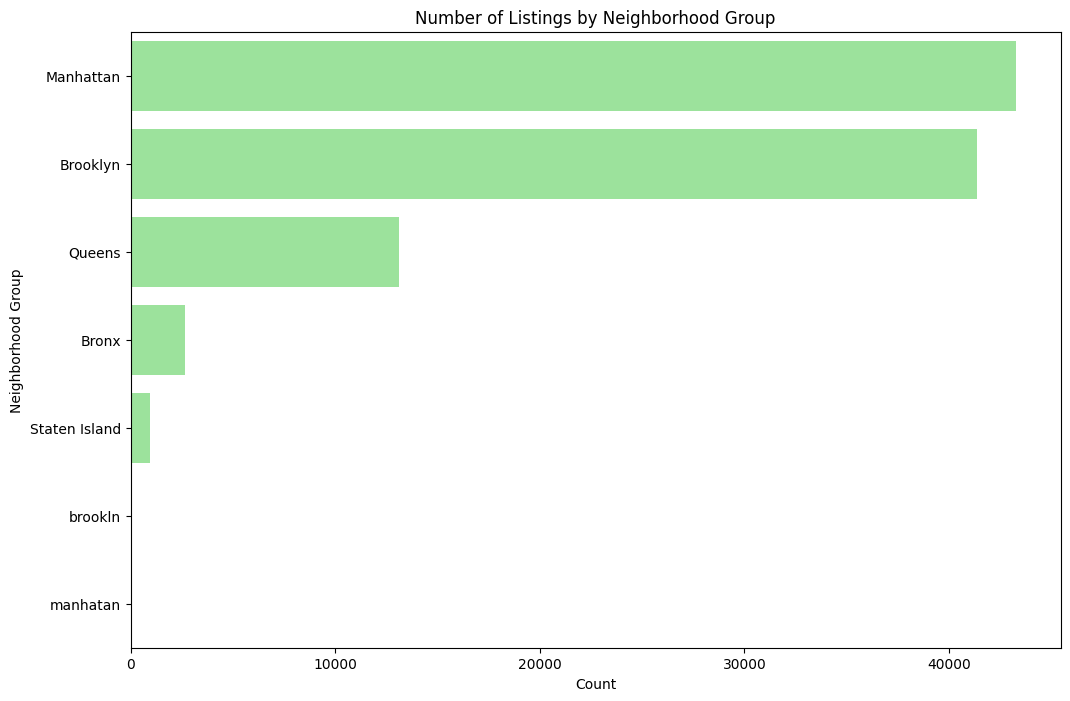

In [10]:
plt.figure(figsize=(12, 8))
sns.countplot(y='neighbourhood group', data=df,color="lightgreen" , order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.xlabel('Count')
plt.ylabel('Neighborhood Group')
plt.show()

### Insights: Number of Listings by Neighborhood Group

*   The `Number of Listings by Neighborhood Group` chart clearly demonstrates that Manhattan and Brooklyn are the dominant boroughs in terms of Airbnb listing volume, significantly surpassing Queens, The Bronx, and Staten Island.
*   This highlights these two boroughs as primary centers for short-term rentals, likely due to their high population density, tourist appeal, and commercial activity.
*   The disparity in listing counts across neighborhood groups can influence pricing strategies, availability, and local regulations.

## Price vs. Room Type

Visualize the relationship between price and room type.

/tmp/ipykernel_4652/3352285238.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Room Type')


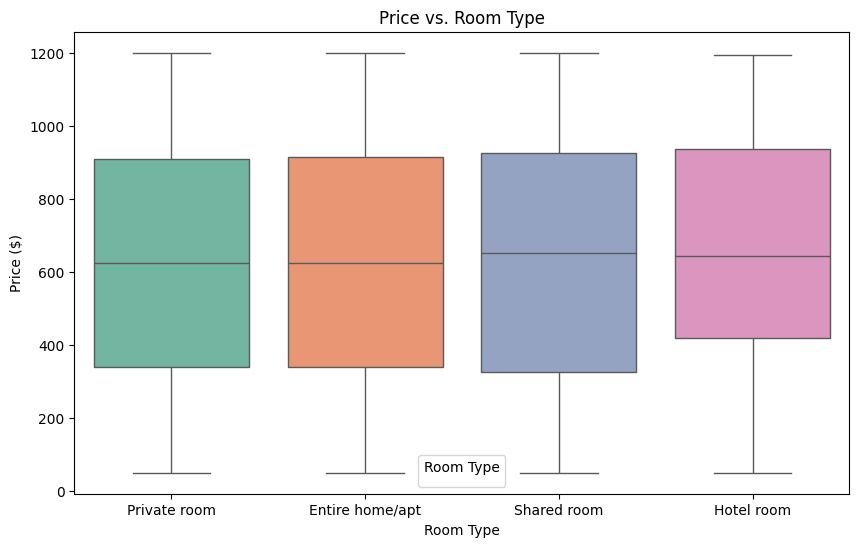

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='room type', y='price', hue='room type', data=df, palette='Set2')
plt.title('Price vs. Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.legend(title='Room Type')
plt.show()

### Insights: Price vs. Room Type

*   The box plot of `Price vs. Room Type` confirms that 'Entire home/apt' listings command the highest median prices and also exhibit the widest price range, indicating a diverse offering from budget-friendly to luxury whole-home rentals.
*   'Private room' listings are moderately priced, as expected, falling between entire homes and shared rooms.
*   'Shared room' listings are consistently the most affordable option, with a narrower price distribution. The presence of numerous outliers in 'Entire home/apt' and 'Private room' categories suggests that there are exceptionally high-priced listings in these types, warranting further investigation if anomaly detection is a goal.

# Reviews Over Time

Plot the number of reviews over time.

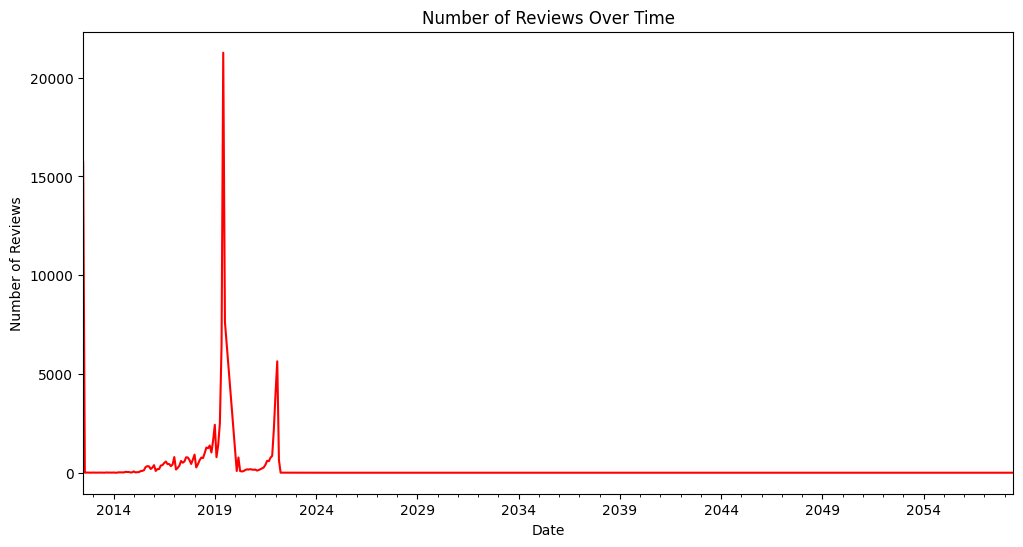

In [12]:
df['last review'] = pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
reviews_over_time.plot(kind='line',color='red')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

### Insights: Number of Reviews Over Time

*   The `Number of Reviews Over Time` plot, while showing some fluctuations, generally indicates a varying trend in review activity. The spike around mid-2019 suggests a period of increased booking or review submissions.
*   There are also some unusual data points, such as reviews recorded in the future (e.g., 2058), which might be data entry errors or placeholders that should be addressed during data cleaning for more accurate time-series analysis.
*   Understanding these trends can help identify peak seasons, the impact of external events, or periods when the platform was more active in collecting reviews.

### Top Hosts by Number of Listings

Visualize the top hosts with the most listings to identify professional hosts or those with multiple properties.

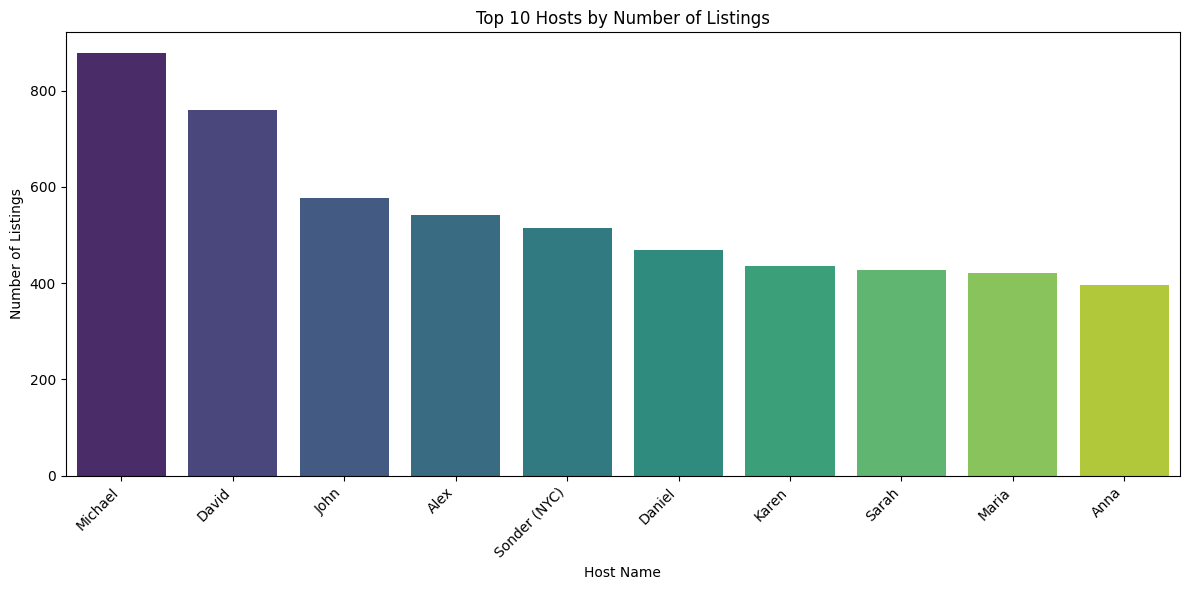

In [13]:
top_hosts = df['host name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_hosts.index, y=top_hosts.values, palette='viridis', hue=top_hosts.index, legend=False)
plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Host Name')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights: Top Hosts by Number of Listings

*   The 'Top 10 Hosts by Number of Listings' visualization clearly shows a few hosts, such as Michael, David, and John, with a significantly higher number of listings compared to others. This indicates the presence of professional landlords or property management companies operating on Airbnb, rather than just individual owners.
*   Identifying these top hosts can be useful for understanding the market structure and potentially for targeted outreach or policy enforcement by Airbnb.

### Geographical Distribution of Listings

Use latitude and longitude to visualize the density of listings on a map-like scatter plot.

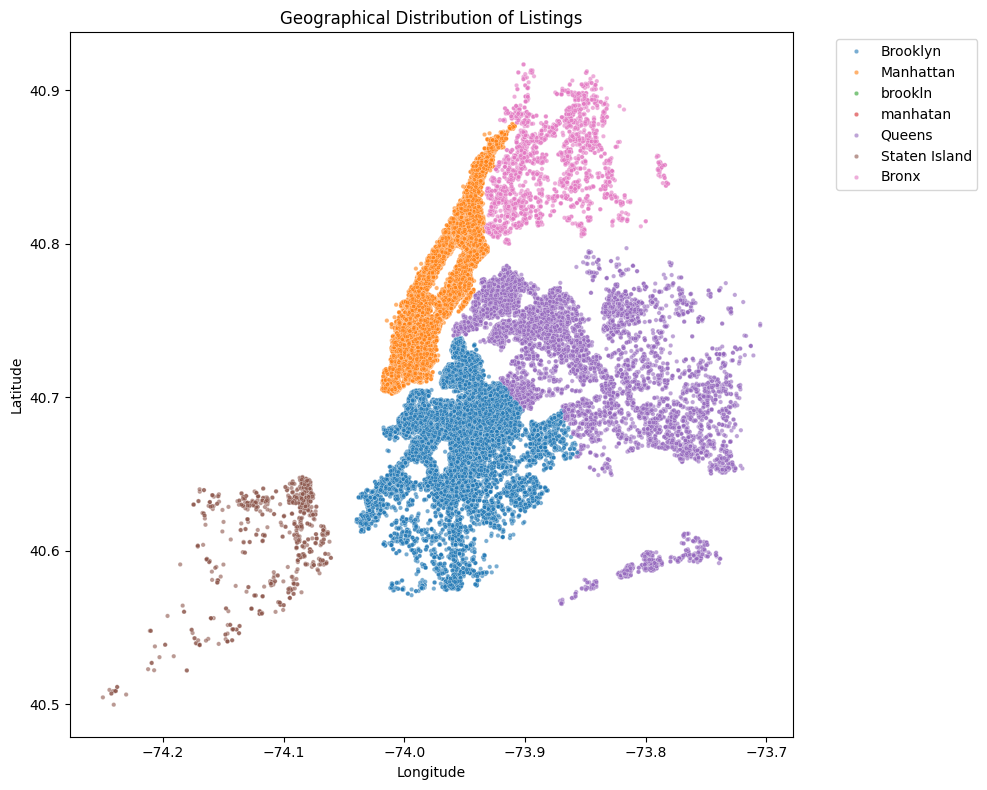

In [14]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='long', y='lat', hue='neighbourhood group', data=df, s=10, alpha=0.6, palette='tab10')
plt.title('Geographical Distribution of Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insights: Geographical Distribution of Listings

*   The scatter plot of `long` vs. `lat` with `neighbourhood group` as hue reveals distinct clusters of listings, primarily concentrated in Manhattan, Brooklyn, and Queens.
*   Manhattan and Brooklyn appear to have the highest density of listings, especially in central areas, aligning with general perceptions of these boroughs as major tourist and residential hubs.
*   There are fewer listings in areas like Staten Island and The Bronx, suggesting lower Airbnb presence or different market dynamics there. The geographical distribution confirms that listing availability is not uniform across all neighborhood groups.

### Correlation Matrix of Numerical Features

Explore the relationships between numerical variables using a correlation heatmap.

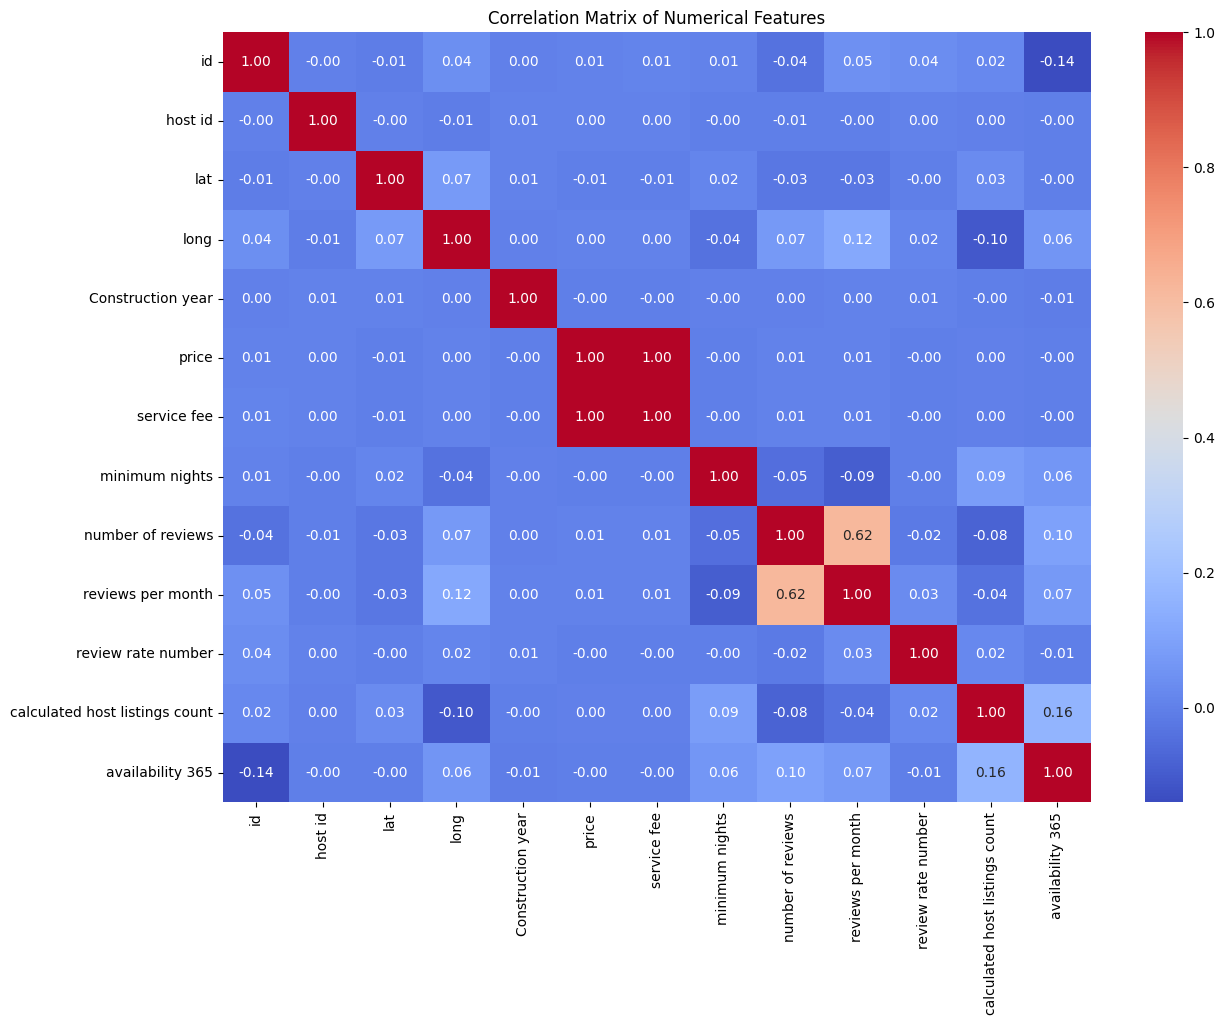

In [15]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Insights: Correlation Matrix of Numerical Features

*   The correlation heatmap shows various relationships between numerical features.
*   `price` and `service fee` show a strong positive correlation, which is expected as service fees are often a percentage of the listing price.
*   `number of reviews` and `reviews per month` also exhibit a strong positive correlation, indicating that listings with more reviews generally also receive reviews more frequently.
*   `calculated host listings count` has a weak positive correlation with `number of reviews` and `reviews per month`, suggesting that hosts with more listings might (slightly) tend to have more reviewed properties, but it's not a very strong driver.
*   Latitude (`lat`) and Longitude (`long`) have a weak positive correlation, which might be due to the city's geographical layout.
*   Notably, `minimum nights` shows very little correlation with other variables, suggesting that the minimum stay requirement might not be directly influenced by or heavily influencing other numerical factors in a linear fashion.
*   `availability 365` seems to have a low correlation with most other features, implying that the number of available days is somewhat independent of factors like price, reviews, or location coordinates.

## Consolidated Insights from Airbnb Data Analysis

Based on the visualizations and exploratory data analysis, here's a summary of the key insights:

### 1. Distribution of Prices
*   The distribution of listing prices is heavily right-skewed, indicating that most listings are at lower price points, with a long tail of fewer, very expensive listings. There are likely significant outliers at the higher end.

### 2. Room Type Distribution
*   'Entire home/apt' and 'Private room' are the most common listing types, significantly outnumbering 'Shared room'.

### 3. Number of Listings by Neighborhood Group
*   Manhattan and Brooklyn are the dominant boroughs in terms of Airbnb listing volume, significantly surpassing Queens, The Bronx, and Staten Island. This highlights these two boroughs as primary centers for short-term rentals.

### 4. Price vs. Room Type
*   'Entire home/apt' listings command the highest median prices and show the widest price range. 'Private room' listings are moderately priced, and 'Shared room' listings are the most affordable.

### 5. Number of Reviews Over Time
*   The review activity shows fluctuations, with a notable spike around mid-2019. There are some unusual data points (reviews in the future), suggesting potential data entry errors that need cleaning for accurate time-series analysis.

### 6. Top Hosts by Number of Listings
*   A few hosts (e.g., Michael, David, John) have a significantly higher number of listings, indicating the presence of professional landlords or property management companies rather than just individual owners.

### 7. Geographical Distribution of Listings
*   Listings are primarily concentrated in Manhattan, Brooklyn, and Queens, with Manhattan and Brooklyn showing the highest density. This confirms non-uniform listing availability across different neighborhood groups.

### 8. Correlation Matrix of Numerical Features
*   `price` and `service fee` have a strong positive correlation, which is expected. `number of reviews` and `reviews per month` also show a strong positive correlation.
*   `minimum nights` and `availability 365` have very low correlations with other numerical variables, suggesting they are relatively independent factors.

## Business Impacts and Analytics Suggestions

Based on the consolidated insights, here are some business impacts and actionable suggestions:

### 1. Pricing Strategy Optimization
*   **Impact:** The right-skewed price distribution indicates a highly competitive market at lower price points and less competition at higher-end segments. Outliers suggest opportunities for premium offerings.
*   **Suggestion:** Implement dynamic pricing models that consider room type, neighborhood, availability, and seasonality. For premium listings, focus on unique amenities or experiences to justify higher prices. For competitive segments, explore strategies like offering discounts for longer stays or off-peak bookings.

### 2. Market Focus and Expansion
*   **Impact:** Manhattan and Brooklyn dominate the market, while other boroughs like The Bronx and Staten Island have significantly fewer listings. This imbalance can represent untapped potential or saturated markets.
*   **Suggestion:** For hosts and investors, target Manhattan and Brooklyn for high-demand, high-return properties, but be prepared for intense competition. Explore expansion opportunities in less saturated markets like The Bronx or Staten Island, focusing on local attractions and amenities to attract niche markets.

### 3. Host Management and Engagement
*   **Impact:** The presence of professional hosts with multiple listings significantly influences market supply. Identifying top hosts can reveal best practices.
*   **Suggestion:** For platforms like Airbnb, develop tiered support and incentive programs for professional hosts. For individual hosts, learning from top hosts' strategies (e.g., in listing descriptions, photos, amenities) can improve performance. Consider host training programs on optimizing listings and guest experience.

### 4. Listing Improvement and Differentiation
*   **Impact:** 'Entire home/apt' and 'Private room' are the most common and profitable types. The wide price range for 'Entire home/apt' suggests diverse value propositions.
*   **Suggestion:** Hosts should focus on enhancing 'Entire home/apt' and 'Private room' listings with high-quality photos, detailed descriptions, and unique amenities. Invest in features that justify higher prices, such as modern decor, premium facilities, or excellent guest services. For 'Shared room' listings, emphasize affordability, cleanliness, and security.

### 5. Data Quality and Predictive Analytics
*   **Impact:** Inconsistent data (e.g., future review dates) can skew time-series analysis and hinder accurate forecasting.
*   **Suggestion:** Implement robust data validation during collection. Leverage clean review data to predict booking trends, identify peak seasons, and anticipate demand. Develop a model to forecast occupancy rates and optimal pricing based on historical review patterns and seasonality.

### 6. Correlation-based Feature Engineering
*   **Impact:** Strong correlations between `price` and `service fee`, and `number of reviews` and `reviews per month`, can be used in predictive models. Low correlation with `minimum nights` and `availability 365` suggests they might need different analytical approaches.
*   **Suggestion:** When building machine learning models for price prediction or demand forecasting, explicitly include correlated features like 'service fee' or 'reviews per month'. For features with low correlation, consider non-linear relationships or interaction terms, or explore alternative data points that might better explain their impact.